## Resume-screening Model

### Life Cycle of a Machine Learning Project

- Uderstanding of the Problem Statement
- Data Collection
- Data checks to perform
- Exploratory data analysis
- Data pre-processing
- Model training
- Choose the best model

#### 1) Problem Statement
- This project will look into the applicants' resume and understands whether the applicant is fit for the role (Best Match) based on other variables such as Job Applicant Name, Age, Gender, Race, Ethnicity, Resume, Job Roles, Job Description


#### 2) Data Collection
- Dataset Source: https://www.kaggle.com/datasets/surendra365/recruitement-dataset/data
- The data consists of 9 columns and 10000 rows

### 2.1 Import Data and Required Packages
#### Importing Pandas, NumPy, Matplotlib, Seaborn and Warnings Library

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('data/job_applicant_dataset.csv')

#### Show Top 5 Records

In [4]:
df.head()

,Job Applicant Name,Age,Gender,Race,Ethnicity,Resume,Job Roles,Job Description,Best Match
0,Daisuke Mori,29,Male,Mongoloid/Asian,Vietnamese,"Proficient in Injury Prevention, Motivation, N...",Fitness Coach,A Fitness Coach is responsible for helping cl...,0
1,Taichi Shimizu,31,Male,Mongoloid/Asian,Filipino,"Proficient in Healthcare, Pharmacology, Medica...",Physician,"Diagnose and treat illnesses, prescribe medica...",0
2,Sarah Martin,46,Female,White/Caucasian,Dutch,"Proficient in Forecasting, Financial Modelling...",Financial Analyst,"As a Financial Analyst, you will be responsibl...",0
3,Keith Hughes,43,Male,Negroid/Black,Caribbean,"Proficient in Budgeting, Supply Chain Optimiza...",Supply Chain Manager,A Supply Chain Manager oversees the entire sup...,1
4,James Davis,49,Male,White/Caucasian,English,"Proficient in Logistics, Negotiation, Procurem...",Supply Chain Manager,A Supply Chain Manager oversees the entire sup...,1


Shape of the dataset

In [5]:
df.shape

(10000, 9)

### 2.2 Dataset Information
- Job Applicant Name: name of the applicant
- Age: Age of the applicant
- Gender: Sex of the applicant -> (Male/Female)
- Race: Applicant's Race -> (Mongoloid/Asian, White/Caucasian, Negroid/Black, etc.)
- Ethnicity: Applicant's Ethnicity -> (Vietnamese, Filipino, Dutch, etc.)
- Resume: Applicant's Resume
- Job Roles: Job listing
- Job Description: The description of the job
- Best Match: is the applicant fit for the role

### 3. Data checks to perform
- Check missing values
- Check duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of dataset
- Check various categories present in the different categorical column

#### 3.1 Check Missing Values

In [6]:
df.isna().sum()

Job Applicant Name    0
Age                   0
Gender                0
Race                  0
Ethnicity             0
Resume                0
Job Roles             0
Job Description       0
Best Match            0
dtype: int64

Insights: There are no missing values in the dataset

#### 3.2 Check Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

Insights: There are not duplicate values in the dataset

#### 3.3 Check Data Type

In [8]:
df.dtypes

Job Applicant Name      str
Age                   int64
Gender                  str
Race                    str
Ethnicity               str
Resume                  str
Job Roles               str
Job Description         str
Best Match            int64
dtype: object

#### 3.4 Check the number of unique values of each columns

In [9]:
df.nunique()

Job Applicant Name     547
Age                     31
Gender                   2
Race                     3
Ethnicity               21
Resume                9996
Job Roles               51
Job Description         51
Best Match               2
dtype: int64

#### 3.5 Check statistics of dataset

In [10]:
df.describe()

,Age,Best Match
count,10000.000000,10000.0000
mean,40.045200,0.4850
std,8.950909,0.4998
min,25.000000,0.0000
25%,32.000000,0.0000
50%,40.000000,0.0000
75%,48.000000,1.0000
max,55.000000,1.0000


Insights: There is no correlation between Age and Best Match

#### 3.6  Exploring Data

In [11]:
# define numerical & categorical columns
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()

# print columns
print('We have {} numerical features: {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features: {}'.format(len(categorical_features), categorical_features))

We have 2 numerical features: ['Age', 'Best Match']

We have 7 categorical features: ['Job Applicant Name', 'Gender', 'Race', 'Ethnicity', 'Resume', 'Job Roles', 'Job Description']


#### 3.7 Exploring Data (Visualization)

#### Best Match Distribution

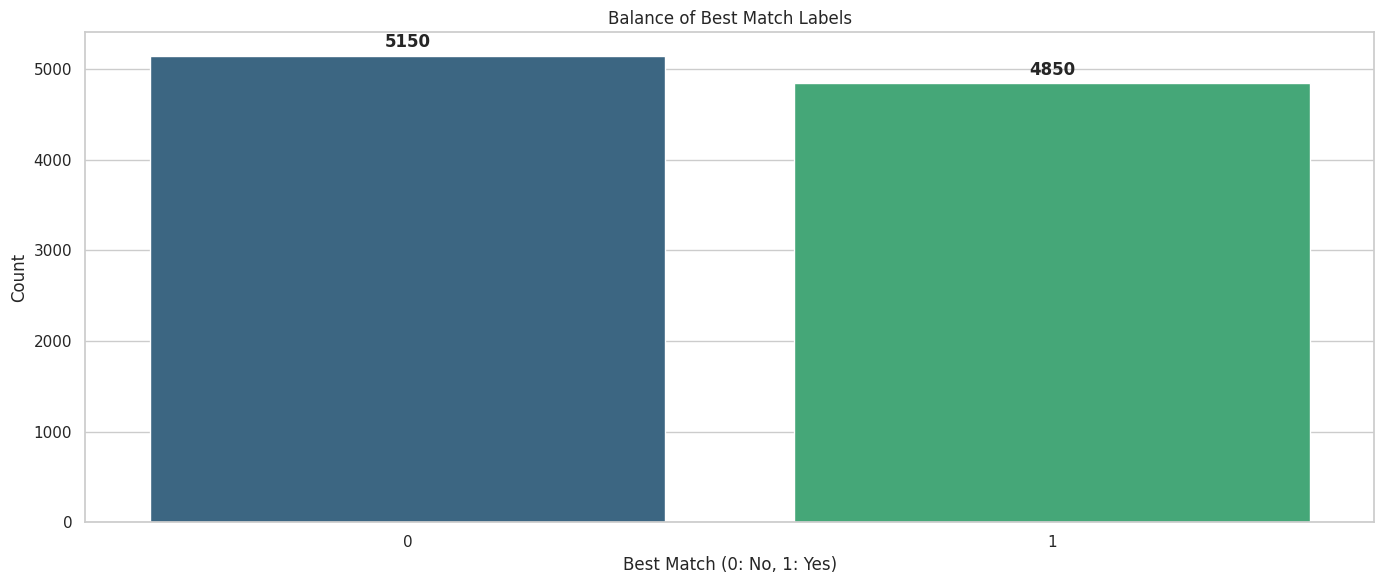

In [29]:
plt.figure(figsize=(14, 6))

ax = sns.countplot(x='Best Match', data=df, palette='viridis')
for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight='bold', padding=3)

plt.title('Balance of Best Match Labels')
plt.xlabel('Best Match (0: No, 1: Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

Insights: The number of best match applicants and non best match applicants are relatively similar, with the number of non best match applicants is slighty more.

#### Top 10 Job Roles with Best Match status

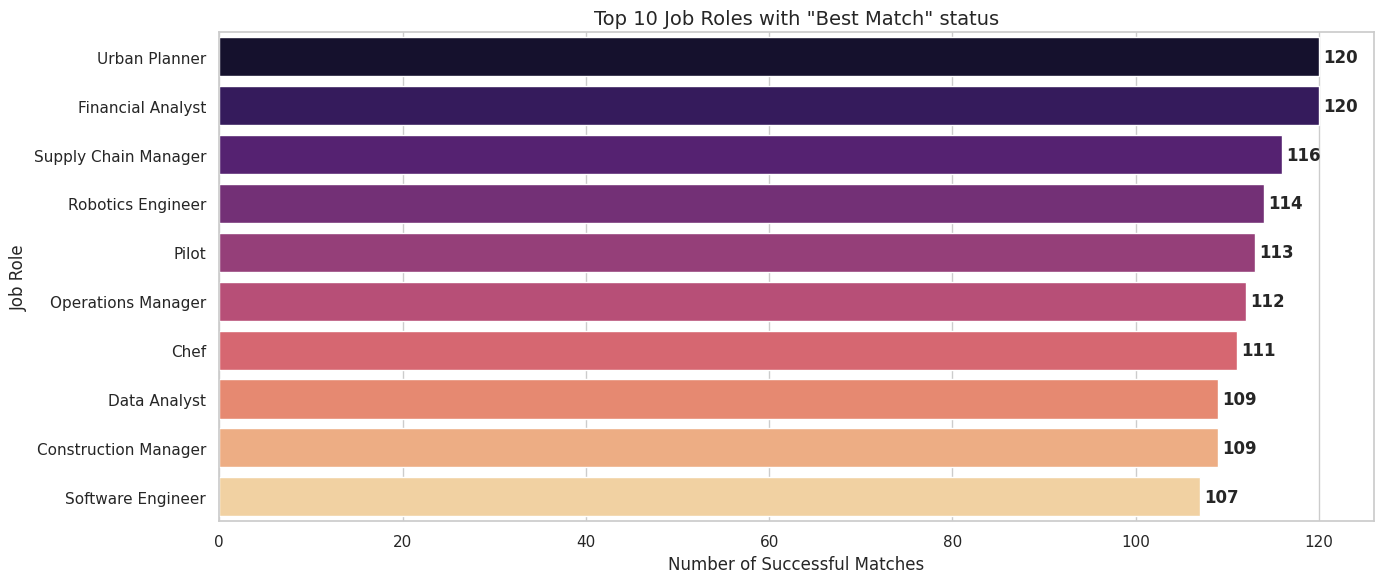

In [31]:
plt.figure(figsize=(14, 6))

best_matches_only = df[df['Best Match'] == 1]

top_roles = best_matches_only['Job Roles'].value_counts().head(10)

ax = sns.barplot(x=top_roles, y=top_roles.index, palette='magma')

for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight='bold', padding=3)

plt.title('Top 10 Job Roles with "Best Match" status', fontsize=14)
plt.xlabel('Number of Successful Matches', fontsize=12)
plt.ylabel('Job Role', fontsize=12)

plt.tight_layout()
plt.show()

Insights:
- Urban Planner and Financial Analyst are tied for the highest number of successful matches with 120 successful outcomes each. This means the dataset contains high-quality resumes for these specific roles, making them the most "recommendable" categories in the current system.
- The Top 10 list is populated by technical and engineering roles, including Robotics Engineer (114), Data Analyst (109), And Software Engineer (107). This indicates that the recommendation system has a strong foundation for STEM-based placements.
- There's a significant presence of management-heavy roles such as Supply Chain Manager (116), Operations Manager  (112), and Construction Manager (109). The system appears to robust at identifying candidates with high-level coordination and project maangement skills.
- The volume of successful matches is remarkably consistent across the top 10 roles, ranging from 107 to 120. This uniform distribution shows that the dataset is well-structured and doesn't suffer from extreme "class imbalance" in its top performing categories, allowing for more reliable model training.

#### Applicants count by Gender

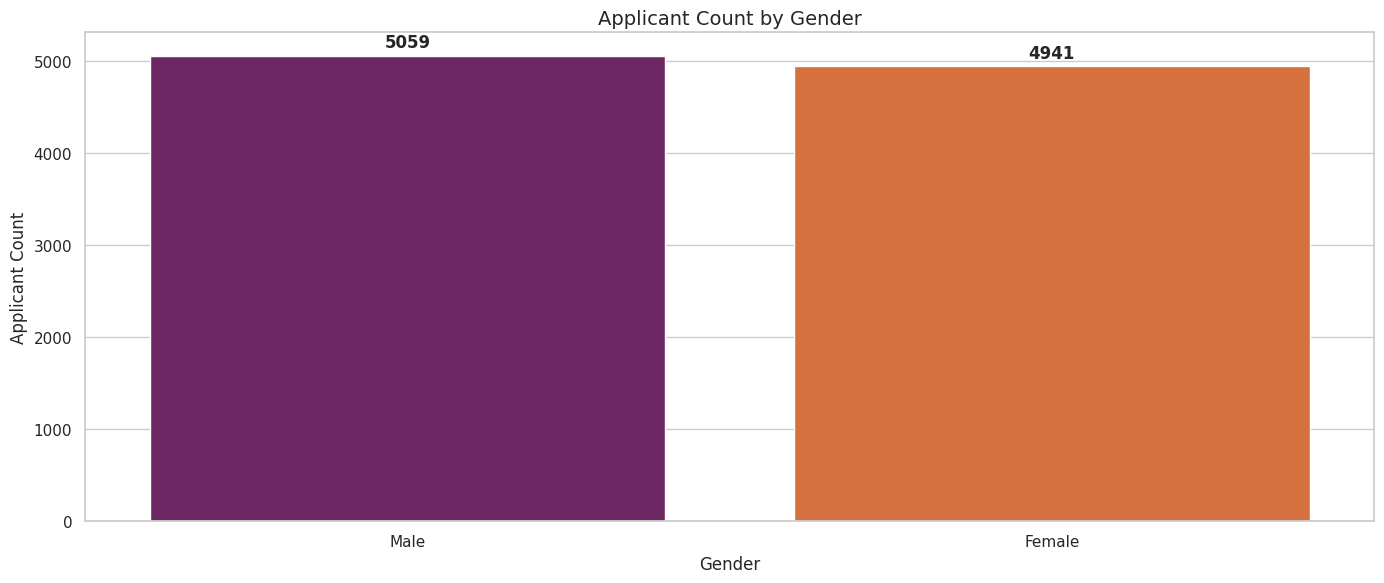

In [40]:
plt.figure(figsize=(14, 6))

ax = sns.countplot(x='Gender', data=df, palette='inferno')
for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight='bold', padding=3)
plt.title('Applicant Count by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Applicant Count', fontsize=12)

plt.tight_layout()
plt.show()

Insights:
- The dataset is almost balanced between Male and Female applicants

#### Applicant count by Race

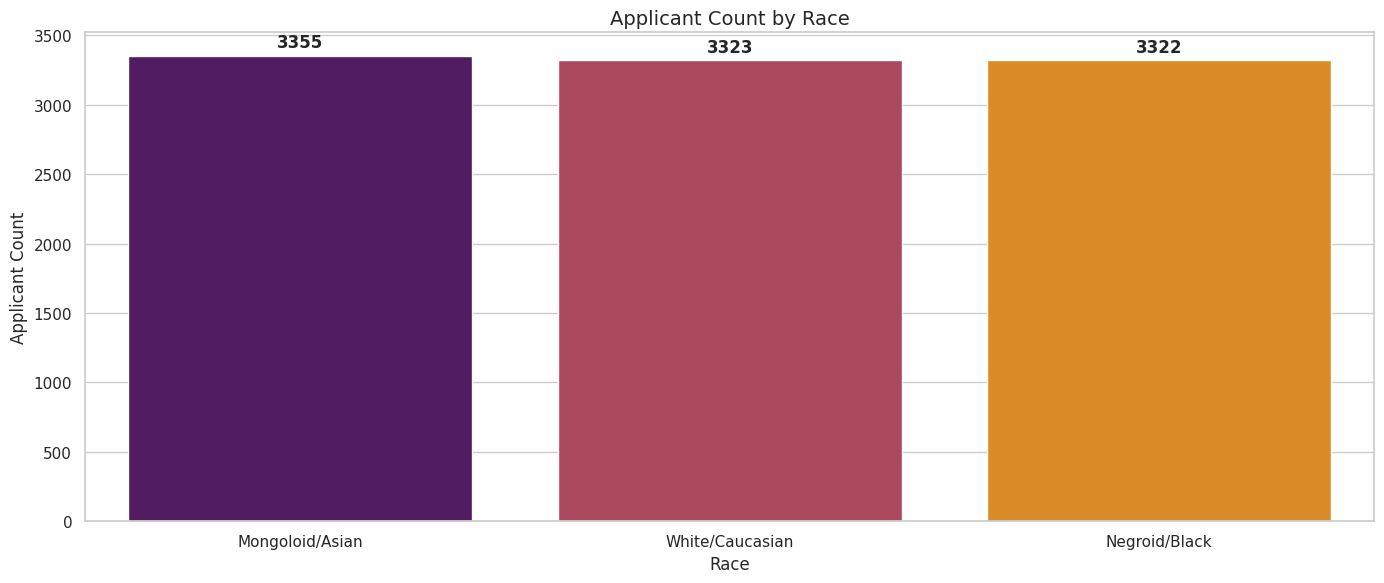

In [41]:
plt.figure(figsize=(14, 6))

ax = sns.countplot(x='Race', data=df, palette='inferno')

for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight='bold', padding=3)

plt.title('Applicant Count by Race', fontsize=14)
plt.xlabel('Race', fontsize=12)
plt.ylabel('Applicant Count', fontsize=12)

plt.tight_layout()
plt.show()

Insights:
- The three categories (Mongoloid/Asian, White/Caucasian, Negroid/Black) are evenly distributed with roughly 3300 applicants each.

#### Applicant count by Ethnicity

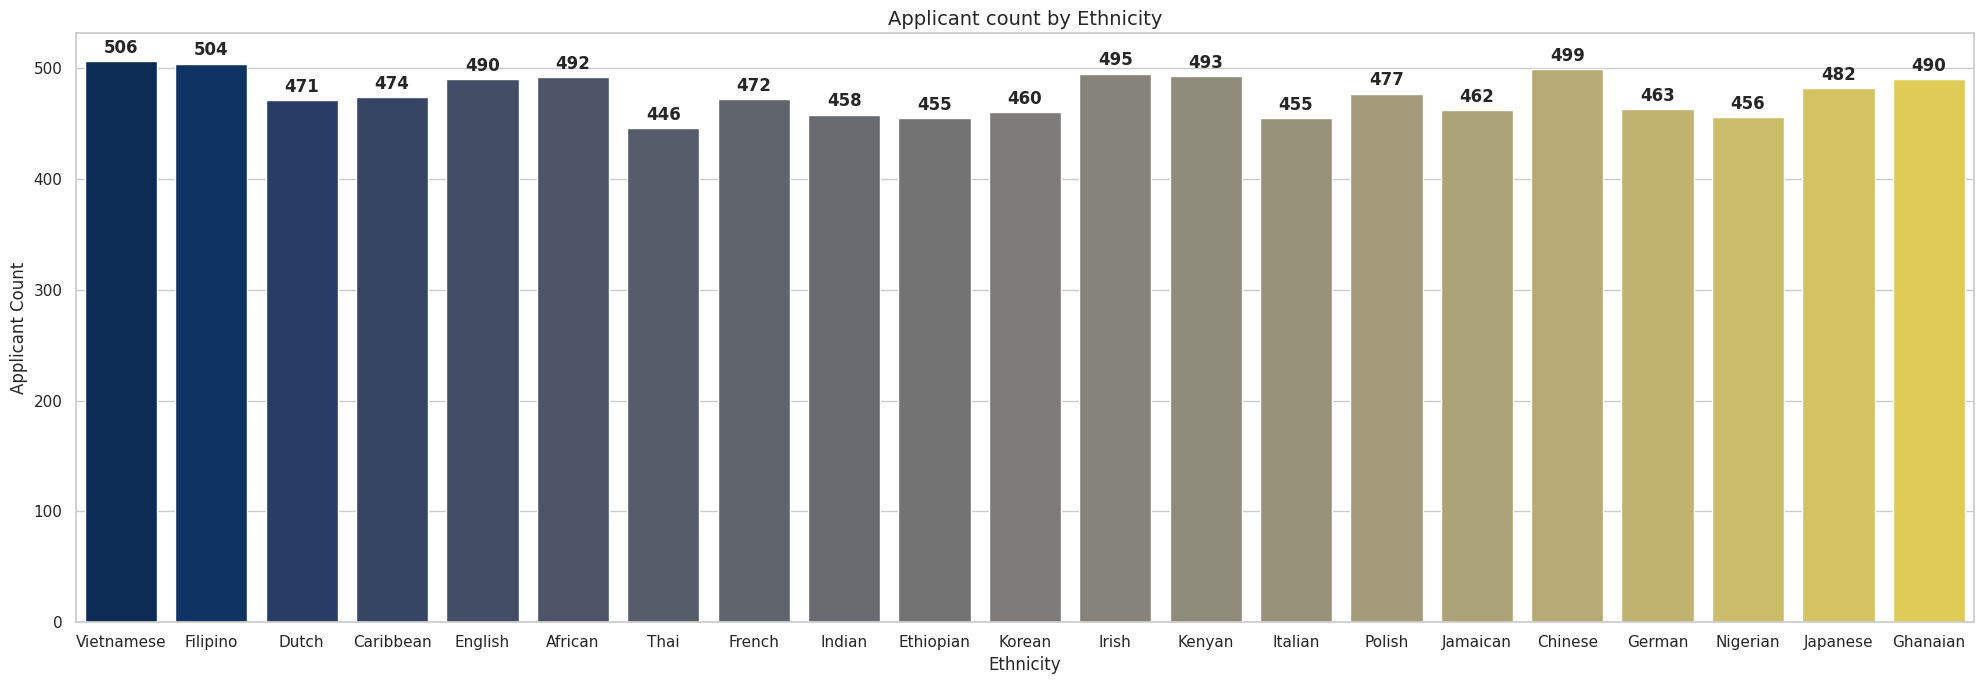

In [48]:
plt.figure(figsize=(20, 7))

ax = sns.countplot(x='Ethnicity', data=df, palette='cividis')

for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight='bold', padding=3)

plt.title('Applicant count by Ethnicity', fontsize=14)
plt.xlabel('Ethnicity', fontsize=12)
plt.ylabel('Applicant Count', fontsize=12)

plt.tight_layout()
plt.show()

Insights:
- There is a wide variety of ethnicities (21 unique values), each wiht approximately 450 - 500 applicants

#### Add a Resume Word Count

In [50]:
df['Resume_Word_Count'] = df['Resume'].apply(lambda x: len(str(x).split()))

print(df[['Resume', 'Resume_Word_Count']].head())

                                              Resume  Resume_Word_Count
0  Proficient in Injury Prevention, Motivation, N...                 39
1  Proficient in Healthcare, Pharmacology, Medica...                 38
2  Proficient in Forecasting, Financial Modelling...                 37
3  Proficient in Budgeting, Supply Chain Optimiza...                 36
4  Proficient in Logistics, Negotiation, Procurem...                 38


#### Resume Word Counts Distribution

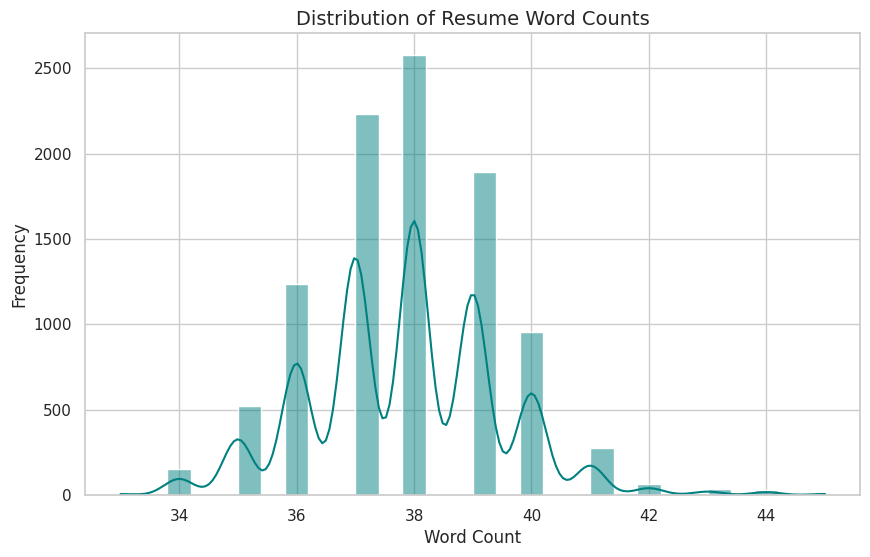

In [53]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Resume_Word_Count'], bins=30, kde=True, color='teal')

plt.title('Distribution of Resume Word Counts', fontsize=14)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Insights:
- The word count is normally distributed, with the frequency is tightly clustered around 38 words, suggesting the resumes are very concise summaries rather than full-length documents

#### Cross-Tabulation Check

Success rate by Gender

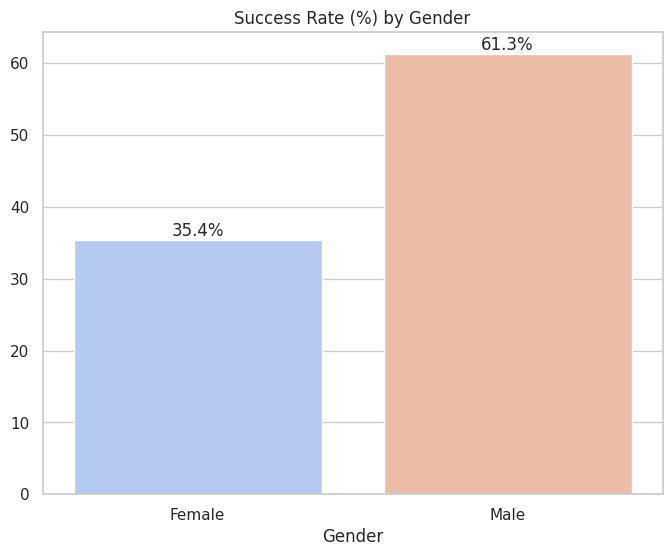

In [ ]:
# Calculate success rates (mean of 0s and 1s multiplied by 100)
gender_success = df.groupby('Gender')['Best Match'].mean() * 100

# Visualize Gender Success Rate
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=gender_success.index, y=gender_success.values, palette='coolwarm')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Success Rate (%) by Gender')
plt.show()

Success Rate by Race

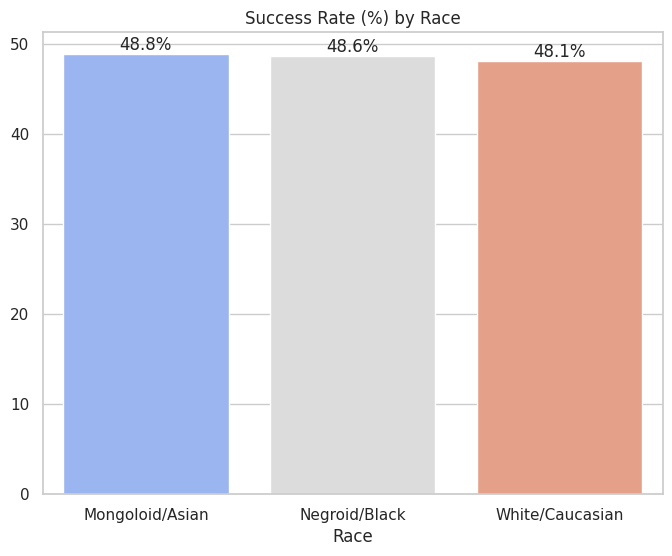

In [62]:
race_success = df.groupby('Race')['Best Match'].mean() * 100

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=race_success.index, y=race_success.values, palette='coolwarm')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Success Rate (%) by Race')
plt.show()

Success Rate by Ethnicity

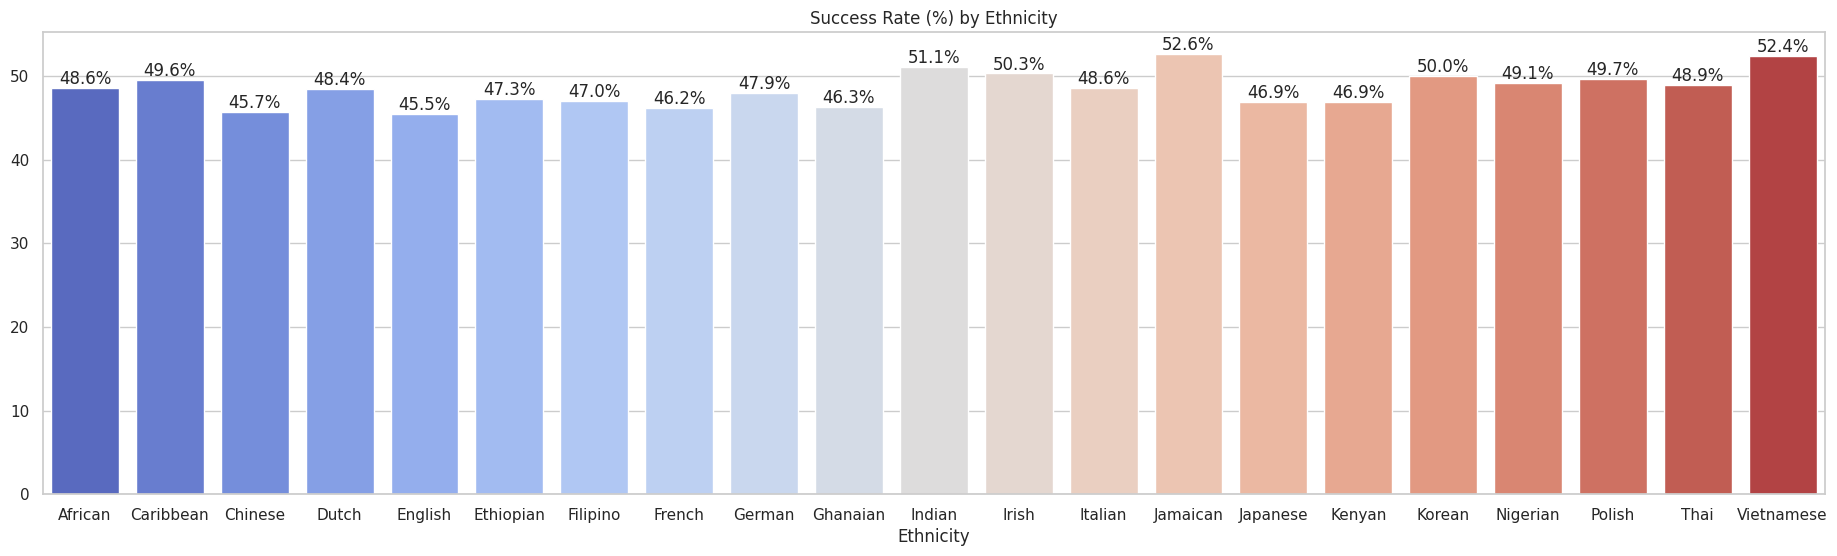

In [70]:
ethnicity_success = df.groupby('Ethnicity')['Best Match'].mean() * 100

plt.figure(figsize=(23, 6))
ax = sns.barplot(x=ethnicity_success.index, y=ethnicity_success.values, palette='coolwarm')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Success Rate (%) by Ethnicity')
plt.show()